# Ten-year dynamic maps and a finite-source light curve

Point lenses move continuously while map construction is temporally batched.
This example uses the same 25-day map cadence and daily source cadence over a
full ten years as the primary production tutorial. Only the first, middle,
and final $1024^2$ point-source maps are copied to CPU. All 147 maps are
streamed through finite-source photometry and released.

The two source bands differ only in Gaussian size, so the larger source
smooths more small-scale magnification structure. Each Gaussian band is
normalized to an observed flux density in Jy. The light curve therefore uses
physical AB magnitudes rather than an unlabeled relative offset.


In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    profiling="detailed",  # opt in to synchronized component timings
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())

import numpy as np


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
distances = mc.LensingDistances(1.0e25, 2.0e25, 1.0e25)
kinematics = mc.SkyProjectedKinematics(
    ra_deg=340.126125, dec_deg=3.358611,
    stellar_dispersion_km_s=170.0, peculiar_velocity_dispersion_km_s=235.0,
    include_cmb_dipole=True, lens_redshift=0.08, source_redshift=0.18, seed=0,
)
bulk_x, bulk_y = kinematics.mean_velocity_uas_per_day(distances)
dispersion = kinematics.component_dispersion_uas_per_day(distances)
stars = mc.PointMassField(
        x_uas=torch.tensor([-0.8, 0.4, 1.1]),
        y_uas=torch.tensor([0.5, -0.7, 0.2]),
        mass_solar=torch.tensor([0.004974, 0.003183, 0.002579]),
        velocity_x_uas_per_day=bulk_x + dispersion * torch.tensor([0.8, -0.5, 0.3]),
        velocity_y_uas_per_day=bulk_y + dispersion * torch.tensor([-0.4, 0.6, 0.2]),
        bulk_velocity_uas_per_day=(bulk_x, bulk_y),
)
geometry = mc.SourceGeometry(
    (65, 65),
    (1.0e11, 1.0e11),
    (4800.0, 7500.0),
    ("blue", "red"),
)
source = mc.GaussianSource(geometry, sigma_m=(4.0e11, 7.0e11))
lens_region = mc.PlaneRegion((6.0, 6.0))
# This tutorial intentionally follows a 2 uas map around a much smaller
# Gaussian source. PlaneGrid is the advanced override for that use case.
source_grid = mc.PlaneGrid((1024 if use_cuda else 256,) * 2, (2.0, 2.0))
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
method = mc.production_ipm_config(
    rays=10_000_000 if use_cuda else 262_144,
)
schedule = mc.production_dynamic_config()
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(convergence=0.25, shear=0.10), distances=distances,
    stars=stars, source=source, source_grid=source_grid, lens_region=lens_region,
    duration_days=3650.0, runtime=runtime_config,
)


## Tabulated trajectories

`TabulatedTrajectory` represents a path sampled at known observer-frame epochs.
It is useful for measured astrometry or trajectories integrated elsewhere. Pass
it as `trajectory=tabulated_trajectory` when requesting maps on the same ordered
time grid. Interpolate the positions explicitly before construction when the
simulation requires another cadence. The main example below keeps its centered
trajectory so its existing figure is unchanged.


In [3]:
# A measured or externally integrated path can be supplied at exact epochs.
tabulated_positions = torch.stack((
    0.10 * torch.sin(2.0 * torch.pi * map_times / 3650.0),
    0.05 * torch.cos(2.0 * torch.pi * map_times / 3650.0),
), dim=1)
tabulated_trajectory = mc.TabulatedTrajectory(map_times, tabulated_positions)
print('Tabulated trajectory shape:', tuple(
    tabulated_trajectory.position_uas(map_times).shape
))


Tabulated trajectory shape: (147, 2)


In [4]:
selected_times = (0.0, 1825.0, 3650.0)
curve = system.light_curve(
    map_times,
    flux_times_days=flux_times,
    method=method,
    schedule=schedule,
    keep_maps_at_days=selected_times,
)
print("Map epochs:", len(map_times), "daily light-curve samples:", len(flux_times))
print("Retained map times:", curve.map_times_days.tolist())
print("Delivered runtime [s]:", curve.timing.delivered_seconds)


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\solvers\ipm.py:902: CompilationWarning: Compilation event 1: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(
C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\solvers\ipm.py:1291: CompilationWarning: Compilation event 2: preparing a new Triton specialization for batched IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


Map epochs: 147 daily light-curve samples: 3651
Retained map times: [0.0, 1825.0, 3650.0]
Delivered runtime [s]: 24.819153200020082


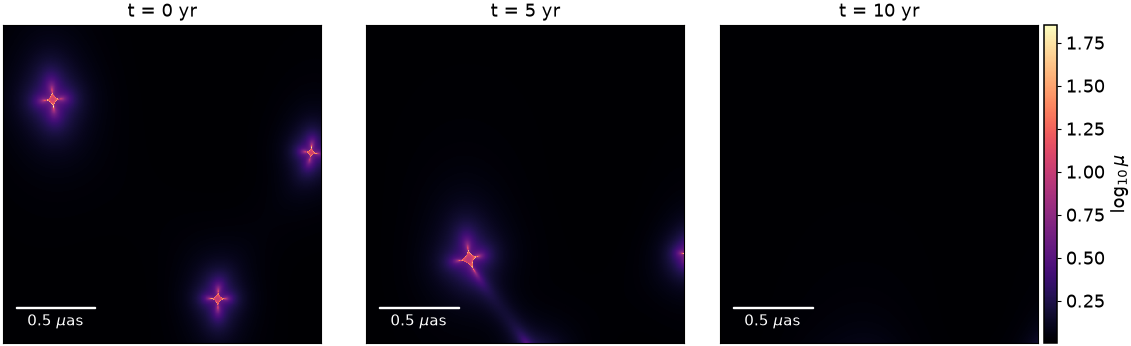

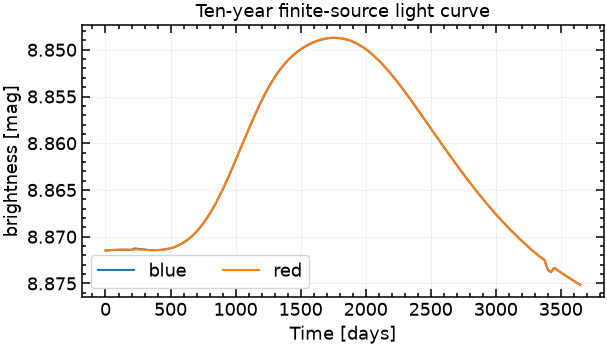

In [5]:
maps = list(curve.maps)
log_values = [np.log10(np.clip(item.numpy(), 1.0e-12, None)) for item in maps]
vmin = min(float(values.min()) for values in log_values)
vmax = max(float(values.max()) for values in log_values)
figure, axes = plt.subplots(1, 3, figsize=(11.7, 3.7))
for ax, item in zip(axes, maps, strict=True):
    mcp.plot_magnification_map(
        item,
        ax=ax,
        log10=True,
        colorbar=False,
        vmin=vmin,
        vmax=vmax,
        scale_bar_uas=0.5,
        show_axes=False,
        title=f"t = {item.time_days / 365.0:.0f} yr",
    )
mcp.panel_colorbar(figure, axes[-1], axes[-1].images[0], label=r"$\log_{10}\mu$")
figure.tight_layout()

figure, ax = mcp.plot_light_curve(
    curve,
    magnitude=True,
    normalize=False,
    title="Ten-year finite-source light curve",
)
figure.tight_layout()
